In [1]:
from utils import make_chirp
import config
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

Found chirps at: [ 4023  9047 14071 19095 24119 29143 34167 39191 44215 49239]
Expected start:  [ 4000  9024 14048 19072 24096 29120 34144 39168 44192 49216]


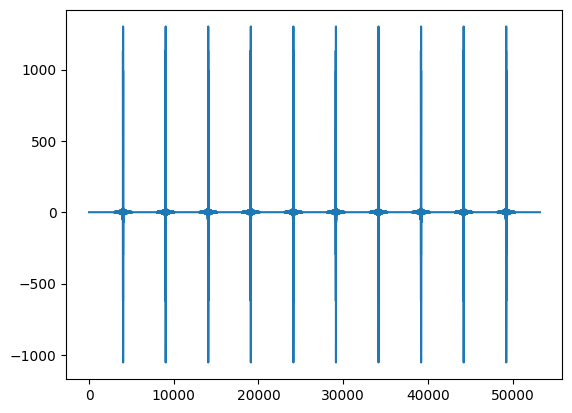

In [2]:
from scipy.signal import find_peaks

def find_chirp_in_signal(signal, num_chirps=None):
    """
    Find chirp locations in signal using cross-correlation and peak detection.
    
    Args:
        signal: Input signal to search
        num_chirps: Expected number of chirps (optional). If provided, returns only top N peaks.
    
    Returns:
        Sorted array of chirp start indices
    """
    reference_chirp = make_chirp(config.CHIRP_LOW, config.CHIRP_HIGH, config.CHIRP_SAMPLES)
    
    # Cross-correlation (gives correlation for each lag)
    correlation = np.correlate(signal, reference_chirp, mode='valid')
    plt.plot(correlation)
    # Much stricter threshold and find peaks
    threshold = np.max(correlation) * 0.7
    peaks, properties = find_peaks(correlation, height=threshold, distance=config.CHIRP_SAMPLES*1.5)
    
    # Sort by correlation magnitude (descending)
    peak_indices = peaks[np.argsort(properties['peak_heights'])[::-1]]
    
    # If expected number given, keep only top N
    if num_chirps is not None:
        peak_indices = peak_indices[:num_chirps]
    
    # Convert correlation indices to signal indices
    # With 'valid' mode: peak_idx in correlation = chirp_start in signal
    chirp_starts = np.sort(peak_indices)
    
    return chirp_starts


# Test it
guard = np.random.normal(0,0, config.CHIRP_SPACING)
chirps = [guard]
for i in range(10):
    chirps.append(make_chirp(config.CHIRP_LOW, config.CHIRP_HIGH, config.CHIRP_SAMPLES)) #+ np.random.normal(0,0.01,config.CHIRP_SAMPLES))
    chirps.append(guard)



signal = np.concatenate(chirps)

channel = np.random.normal(0, 1, 30)
recv = np.convolve(signal, channel)

chirp_starts = find_chirp_in_signal(recv[:signal.size], num_chirps=10)
expected_start =  np.arange(0,10,1)*(config.CHIRP_SAMPLES + config.CHIRP_SPACING) + config.CHIRP_SPACING

#plt.plot(signal, label='signal')
#plt.plot(recv, label='received_chirps')
#plt.legend()
#plt.show()

print("Found chirps at:", chirp_starts)
print("Expected start: ", expected_start)

In [3]:
def estimte_symbol_offset(chirp_starts: np.ndarray):
    """
    Given the observed locations of the chirp peaks can estimate symbol time offset

    Args:
        chirp_starts (np.ndarray): location of chirp
        signal (np.ndarray): received signal
    """
    chirp_spacing = config.CHIRP_SPACING + config.CHIRP_SAMPLES # Distance between start of 2 chirps
    measured_spacing = np.diff(chirp_starts)
    
    sto_offset = np.mean(measured_spacing - chirp_spacing)
    return sto_offset

print(estimte_symbol_offset(chirp_starts))

0.0


True main tap: 17
Estimated main tap: 0


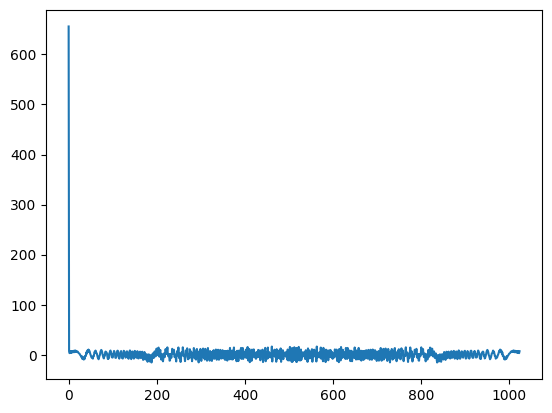

In [ ]:
from scipy.linalg import toeplitz

def make_conv_matrix(x, L):
    x = np.asarray(x)
    N = len(x)

    col = np.concatenate([x, np.zeros(L - 1)])
    row = np.zeros(L)
    row[0] = x[0]

    return toeplitz(col, row)


def estimate_channel_from_chirps(rx, chirp_starts, L_est=64, reg=1e-5):
    x = make_chirp(
        config.CHIRP_LOW,
        config.CHIRP_HIGH,
        config.CHIRP_SAMPLES
    )
    plt.plot(np.fft.fft(x))
   

    X = make_conv_matrix(x, L_est)
    seg_len = X.shape[0]

    A = np.zeros((L_est, L_est))
    b = np.zeros(L_est)

    count = 0

    for start in chirp_starts:
        start = int(start)
        end = start + seg_len

        if end > len(rx):
            continue

        y = rx[start:end]

        A += X.T @ X
        b += X.T @ y
        count += 1

    if count == 0:
        raise ValueError("No valid chirp segments available.")

    h_hat = np.linalg.solve(A + reg * np.eye(L_est), b)

    return h_hat

h_hat = estimate_channel_from_chirps(
    rx=recv,
    chirp_starts=chirp_starts,
    L_est=64,
    reg=1e-5
)

##plt.plot(np.abs(channel), label="true channel")
#plt.plot(np.abs(h_hat[:len(channel)]), label="estimated channel")
#plt.legend()
#plt.show()

print("True main tap:", np.argmax(np.abs(channel)))
print("Estimated main tap:", np.argmax(np.abs(h_hat)))